=== 1. DATA LOADING AND NLP CURATION ===
Data loading complete: Processed 714 herbs.

=== FIGURE 1: CORE KNOWLEDGE GRAPH (TRIPARTITE LAYOUT) ===


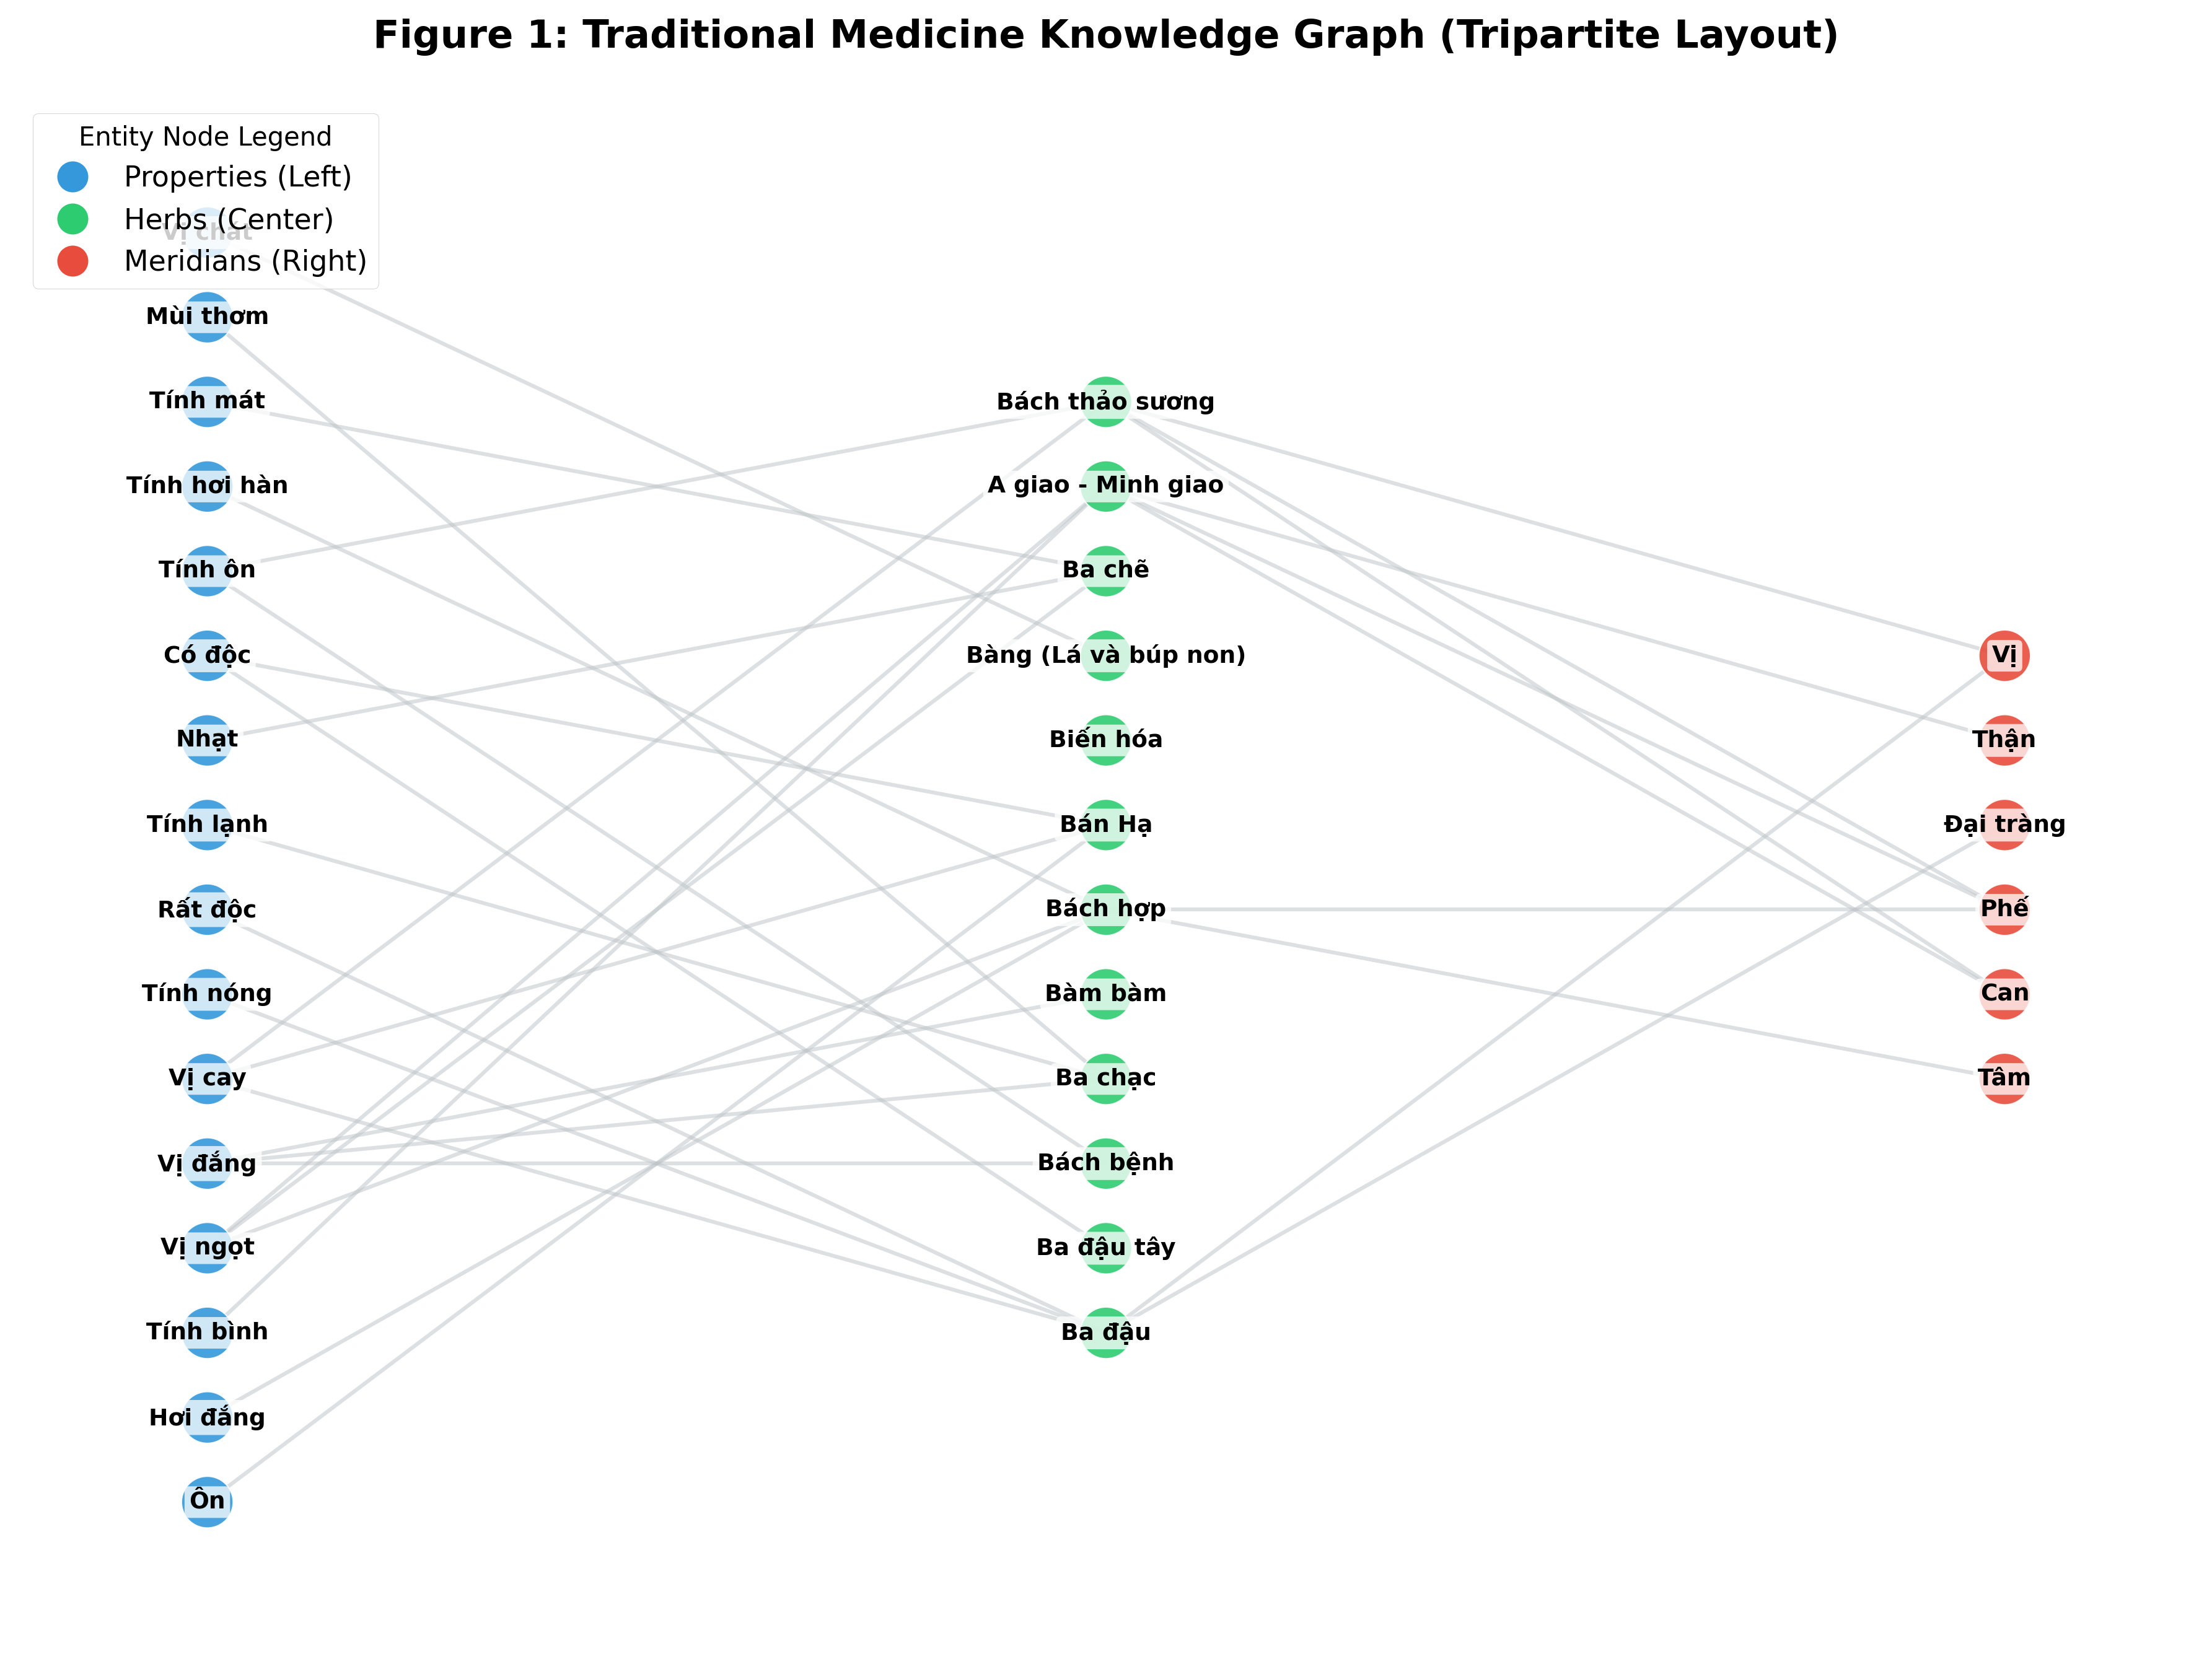


=== FIGURE 2: HERB-HERB SIMILARITY BACKBONE ===


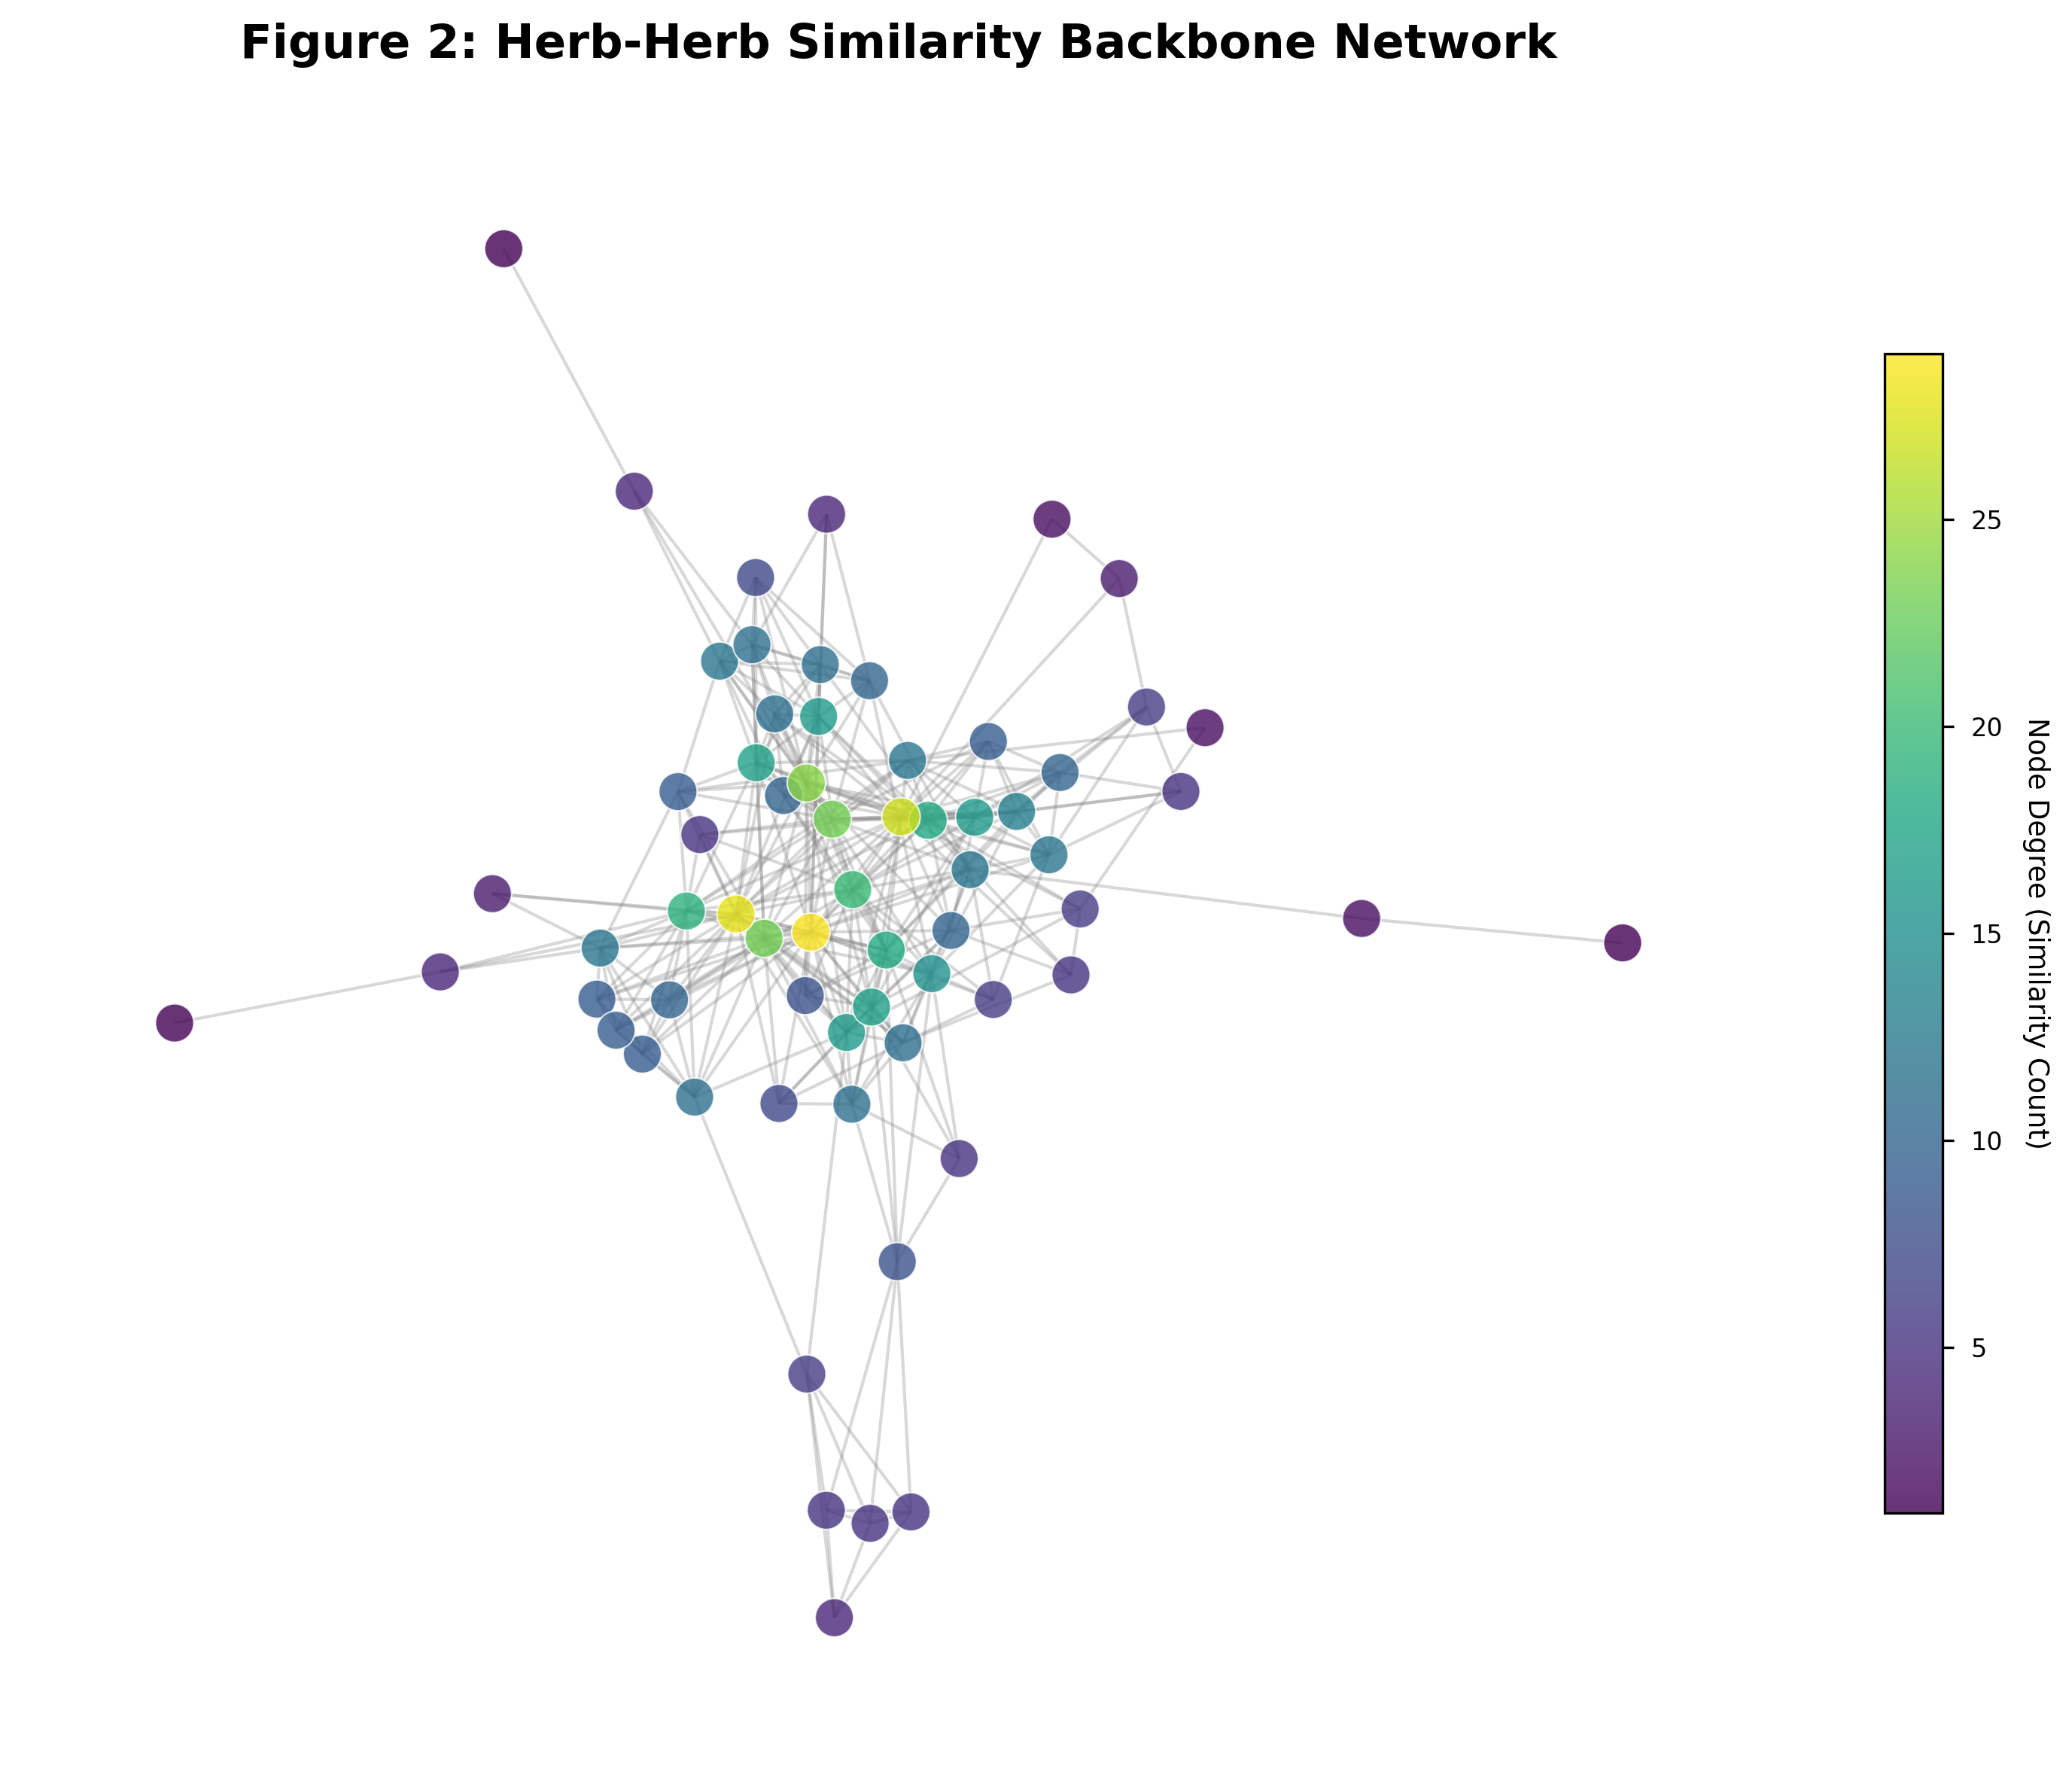


=== PHASE 1 COMPLETE ===
Exported 'curated_tm_features.pkl' for Phase 2 (TDA Vectorization).


In [8]:
# =====================================================================
# 01_Data_Curation_KG.ipynb
# Phase 1: NLP Processing, Tripartite Knowledge Graph, and Similarity Backbone
# =====================================================================
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-paper')

print("=== 1. DATA LOADING AND NLP CURATION ===")
try:
    df = pd.read_csv('ViThuoc_final.csv')
except FileNotFoundError:
    print("ERROR: Please upload 'ViThuoc_final.csv' to the Colab environment.")
    exit()

# Dynamically identify columns to prevent KeyError
cols = [c.lower().strip() for c in df.columns]
ten_col = next((c for c, lc in zip(df.columns, cols) if 'tên' in lc or 'ten' in lc), df.columns[0])
tinh_vi_col = next((c for c, lc in zip(df.columns, cols) if 'tính' in lc and 'vị' in lc), 'TinhVi')
quy_kinh_col = next((c for c, lc in zip(df.columns, cols) if 'quy' in lc and 'kinh' in lc), 'QuyKinh')

def clean_text(text):
    if pd.isna(text) or '(Không ghi rõ)' in str(text) or '(Không có)' in str(text):
        return []
    text = str(text).replace('.', '').strip()
    return [x.strip().capitalize() for x in re.split(r'[,;+]', text) if x.strip()]

# Create the full Graph
G_bipartite = nx.Graph()
herb_dict = {} # Stores properties for each herb for Phase 2

for index, row in df.iterrows():
    herb = str(row[ten_col]).strip()
    G_bipartite.add_node(herb, type='Herb')
    properties = []

    # Process Meridians (Quy Kinh)
    for qk in clean_text(row[quy_kinh_col]):
        G_bipartite.add_node(qk, type='Meridian')
        G_bipartite.add_edge(herb, qk)
        properties.append(qk)

    # Process Nature/Flavor (Tính Vị)
    for tv in clean_text(row[tinh_vi_col]):
        G_bipartite.add_node(tv, type='Property')
        G_bipartite.add_edge(herb, tv)
        properties.append(tv)

    herb_dict[herb] = set(properties)

print(f"Data loading complete: Processed {len(herb_dict)} herbs.")

# =====================================================================
print("\n=== FIGURE 1: CORE KNOWLEDGE GRAPH (TRIPARTITE LAYOUT) ===")
# CRITICAL: Sort the list to guarantee reproducibility!
core_herbs = sorted(list(herb_dict.keys()))[:12]
ego_G = nx.Graph()

# Build the layered sub-graph for multipartite visualization
for h in core_herbs:
    ego_G.add_node(h, type='Herb', layer=1)
    for n in G_bipartite.neighbors(h):
        if G_bipartite.nodes[n]['type'] == 'Property':
            ego_G.add_node(n, type='Property', layer=0)
        elif G_bipartite.nodes[n]['type'] == 'Meridian':
            ego_G.add_node(n, type='Meridian', layer=2)
        ego_G.add_edge(h, n)

plt.figure(figsize=(12, 9), dpi=300)
pos = nx.multipartite_layout(ego_G, subset_key="layer", align="vertical")

node_colors = []
for node in ego_G.nodes():
    if ego_G.nodes[node].get('type') == 'Herb':
        node_colors.append('#2ecc71') # Center: Green
    elif ego_G.nodes[node].get('type') == 'Meridian':
        node_colors.append('#e74c3c') # Right: Red
    else:
        node_colors.append('#3498db') # Left: Blue

# Draw edges and nodes
nx.draw_networkx_edges(ego_G, pos, edge_color='#bdc3c7', alpha=0.5, width=1.5)
nx.draw_networkx_nodes(ego_G, pos, node_color=node_colors, node_size=400, alpha=0.9, edgecolors='white', linewidths=0.5)

# Beautiful labels with clean white bounding boxes
nx.draw_networkx_labels(ego_G, pos, font_size=9, font_weight='bold',
                        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Properties (Left)', markerfacecolor='#3498db', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Herbs (Center)', markerfacecolor='#2ecc71', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Meridians (Right)', markerfacecolor='#e74c3c', markersize=12)
]
plt.legend(handles=legend_elements, loc='upper left', title="Entity Node Legend", fontsize=11)
plt.title("Figure 1: Traditional Medicine Knowledge Graph (Tripartite Layout)", fontsize=15, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

plt.savefig("Fig1_Core_Knowledge_Graph_EN.png", bbox_inches='tight')
plt.show()

# =====================================================================
print("\n=== FIGURE 2: HERB-HERB SIMILARITY BACKBONE ===")
# Projection: Two herbs are connected if they share >= 2 properties
G_herb = nx.Graph()

# CRITICAL: Sort to ensure reproducibility across executions
herbs_list = sorted(list(herb_dict.keys()))[:150]

for i in range(len(herbs_list)):
    G_herb.add_node(herbs_list[i])
    for j in range(i + 1, len(herbs_list)):
        shared_props = herb_dict[herbs_list[i]].intersection(herb_dict[herbs_list[j]])
        if len(shared_props) >= 2: # Noise filtration threshold
            G_herb.add_edge(herbs_list[i], herbs_list[j], weight=len(shared_props))

# Extract the largest connected component for meaningful TDA later
largest_cc = max(nx.connected_components(G_herb), key=len)
G_herb_core = G_herb.subgraph(largest_cc).copy()

plt.figure(figsize=(10, 8), dpi=300)
pos_herb = nx.spring_layout(G_herb_core, k=0.15, seed=42)
degrees = [G_herb_core.degree(n) for n in G_herb_core.nodes()]

nodes = nx.draw_networkx_nodes(G_herb_core, pos_herb, node_size=150, cmap=plt.cm.viridis,
                               node_color=degrees, alpha=0.8, edgecolors='white', linewidths=0.5)
nx.draw_networkx_edges(G_herb_core, pos_herb, alpha=0.3, edge_color='gray')

cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label("Node Degree (Similarity Count)", rotation=270, labelpad=15)

plt.title("Figure 2: Herb-Herb Similarity Backbone Network", fontsize=15, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()

plt.savefig("Fig2_Herb_Similarity_Network_EN.png", bbox_inches='tight')
plt.show()

# =====================================================================
# Export curated data for the TDA Notebook (Notebook 2)
df['Parsed_TinhVi'] = df[tinh_vi_col].apply(clean_text)
df['Parsed_QuyKinh'] = df[quy_kinh_col].apply(clean_text)
df['All_Properties'] = df['Parsed_TinhVi'] + df['Parsed_QuyKinh']

df_cleaned = df[[ten_col, 'All_Properties']].copy()
df_cleaned.to_pickle('curated_tm_features.pkl')

print("\n=== PHASE 1 COMPLETE ===")
print("Exported 'curated_tm_features.pkl' for Phase 2 (TDA Vectorization).")